# Phase 8 / Final Summary and Results

This notebook consolidates the final outputs of the **Diamond Dynamics: Price Prediction and Market Segmentation** project.

It is aligned with the actual project implementation across:

- data cleaning and preprocessing
- EDA
- feature engineering and selection
- regression training and evaluation
- clustering and cluster naming
- inference utilities
- Streamlit deployment layer

This notebook is intended to act as the **final presentation notebook** for GitHub and portfolio review.

In [5]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 140)

## 1. Resolve project root and important paths

In [6]:
def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    start = start.resolve()

    for path in [start, *start.parents]:
        if (path / "src").exists() and (path / "configs").exists():
            return path

    return Path.cwd().resolve()

project_root = find_project_root()
project_root

WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation')

In [26]:
def first_existing(*relative_paths: str) -> Path | None:
    for rel in relative_paths:
        path = project_root / rel
        if path.exists():
            return path
    return None

paths = {
    "cleaned_data": first_existing("data/processed/diamonds_processed.csv", "data/interim/diamonds_cleaned.csv"),
    "feature_engineered_data": first_existing("data/processed/diamonds_feature_engineered.csv"),
    "regression_input": first_existing("data/processed/regression_model_input.csv", "data/processed/train.csv"),
    "clustering_input": first_existing("data/processed/clustering_model_input.csv", "data/processed/cluster_analysis_dataset.csv"),
    "train_split": first_existing("data/processed/train.csv"),
    "test_split": first_existing("data/processed/test.csv"),
    "regression_metrics": first_existing("artifacts/regression/regression_metrics.csv"),
    "regression_predictions": first_existing("artifacts/regression/regression_predictions.csv"),
    "cluster_comparison": first_existing("artifacts/clustering/silhouette_results.csv"),
    "cluster_summary": first_existing("artifacts/clustering/cluster_summary.csv"),
    "cluster_assignments": first_existing("artifacts/clustering/cluster_assignments.csv", "data/processed/cluster_analysis_dataset.csv"),
    "best_regression_metadata": first_existing("artifacts/regression/best_regression_model_metadata.yaml"),
    "best_clustering_metadata": first_existing("artifacts/clustering/best_clustering_model_metadata.yaml"),
    "regression_report": first_existing("reports/regression_evaluation_report.md"),
    "clustering_report": first_existing("reports/clustering_report.md"),
    "model_selection_report": first_existing("reports/model_selection_report.md"),
    "processing_report": first_existing("reports/processing_report.md"),
    "feature_engineering_report": first_existing("reports/feature_engineering_report.md"),
    "pca_report": first_existing("reports/pca_report.md"),
    "actual_vs_predicted_plot": first_existing("figures/regression/actual_vs_predicted.png"),
    "residuals_plot": first_existing("figures/regression/residuals.png"),
    "model_comparison_plot": first_existing("docs/screenshots/model_comparison_table.png", "figures/regression/regression_models_comparison.png"),
    "cluster_pca_plot": first_existing("docs/screenshots/cluster_pca_plot.png", "figures/clustering/pca_2d_clusters.png"),
    "eda_price_plot": first_existing("docs/screenshots/eda_distribution_price.png", "figures/eda/carat_vs_price_regplot.png"),
    "streamlit_home": first_existing("docs/screenshots/streamlit_home.png"),
    "streamlit_price": first_existing("docs/screenshots/streamlit_price_prediction.png"),
    "streamlit_cluster": first_existing("docs/screenshots/streamlit_cluster_prediction.png"),
}

paths

{'cleaned_data': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/diamonds_processed.csv'),
 'feature_engineered_data': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/diamonds_feature_engineered.csv'),
 'regression_input': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/regression_model_input.csv'),
 'clustering_input': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/clustering_model_input.csv'),
 'train_split': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/train.csv'),
 'test_split': WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation/data/processed/test.csv'),
 'regression_metrics': WindowsPath('F:/DATA SCIENCE/Projects/Diamond D

## 2. Helper functions

In [9]:
def safe_read_csv(path: Path | None):
    if path is None:
        return None
    if path.exists():
        return pd.read_csv(path)
    return None

def safe_read_text(path: Path | None):
    if path is None:
        return None
    if path.exists():
        return path.read_text(encoding="utf-8")
    return None

def display_image(path: Path | None, title: str, figsize=(10, 5)):
    if path is None or not path.exists():
        print(f"Image not found: {title}")
        return
    img = mpimg.imread(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

def print_section(title: str):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

## 3. Load saved outputs

In [10]:
df_cleaned = safe_read_csv(paths["cleaned_data"])
df_featured = safe_read_csv(paths["feature_engineered_data"])
df_regression = safe_read_csv(paths["regression_input"])
df_clustering = safe_read_csv(paths["clustering_input"])
df_train = safe_read_csv(paths["train_split"])
df_test = safe_read_csv(paths["test_split"])

regression_metrics_df = safe_read_csv(paths["regression_metrics"])
regression_predictions_df = safe_read_csv(paths["regression_predictions"])
cluster_comparison_df = safe_read_csv(paths["cluster_comparison"])
cluster_summary_df = safe_read_csv(paths["cluster_summary"])
cluster_assignments_df = safe_read_csv(paths["cluster_assignments"])

processing_report_text = safe_read_text(paths["processing_report"])
feature_engineering_report_text = safe_read_text(paths["feature_engineering_report"])
regression_report_text = safe_read_text(paths["regression_report"])
clustering_report_text = safe_read_text(paths["clustering_report"])
model_selection_report_text = safe_read_text(paths["model_selection_report"])
pca_report_text = safe_read_text(paths["pca_report"])

## 4. Dataset progression across the workflow

In [11]:
dataset_progression = pd.DataFrame(
    {
        "stage": [
            "cleaned / processed dataset",
            "feature engineered dataset",
            "regression input dataset",
            "clustering input dataset",
            "train split",
            "test split",
            "cluster assignments dataset",
        ],
        "rows": [
            len(df_cleaned) if df_cleaned is not None else np.nan,
            len(df_featured) if df_featured is not None else np.nan,
            len(df_regression) if df_regression is not None else np.nan,
            len(df_clustering) if df_clustering is not None else np.nan,
            len(df_train) if df_train is not None else np.nan,
            len(df_test) if df_test is not None else np.nan,
            len(cluster_assignments_df) if cluster_assignments_df is not None else np.nan,
        ],
        "columns": [
            df_cleaned.shape[1] if df_cleaned is not None else np.nan,
            df_featured.shape[1] if df_featured is not None else np.nan,
            df_regression.shape[1] if df_regression is not None else np.nan,
            df_clustering.shape[1] if df_clustering is not None else np.nan,
            df_train.shape[1] if df_train is not None else np.nan,
            df_test.shape[1] if df_test is not None else np.nan,
            cluster_assignments_df.shape[1] if cluster_assignments_df is not None else np.nan,
        ],
    }
)

dataset_progression

,stage,rows,columns
0,cleaned / processed dataset,53940,10
1,feature engineered dataset,53940,22
2,regression input dataset,53940,8
3,clustering input dataset,53940,11
4,train split,43152,8
5,test split,10788,8
6,cluster assignments dataset,53940,12


## 5. Pipeline recap from the actual project functions

In [12]:
pipeline_summary = {
    "data_cleaning": [
        "detect_missing_and_invalid_values",
        "decide_columns_to_drop",
        "mark_invalid_xyz_as_missing",
        "remove_impossible_core_rows",
        "impute_missing_values",
        "build_preprocessing_report",
        "clean_diamonds_dataset",
    ],
    "eda": [
        "build_univariate_summary",
        "build_price_category_summary",
        "build_carat_price_summary",
        "build_correlation_matrix",
        "build_eda_report",
    ],
    "feature_engineering": [
        "load_usd_inr_rate",
        "safe_divide",
        "create_carat_category",
        "add_engineered_features",
        "build_feature_documentation",
        "build_feature_engineering_report",
    ],
    "feature_selection": [
        "compute_regression_feature_importance",
        "identify_high_correlation_pairs",
        "compute_vif_table",
        "select_regression_features",
        "select_clustering_features",
    ],
    "regression_modeling": [
        "infer_feature_types",
        "get_supported_regression_estimators",
        "build_model_pipeline",
        "evaluate_single_regression_model",
        "rank_regression_models",
        "create_regression_evaluation_outputs",
        "train_regression_models",
    ],
    "clustering_modeling": [
        "prepare_clustering_input_dataset",
        "run_elbow_search",
        "train_kmeans_candidates",
        "train_dbscan_candidates",
        "train_agglomerative_candidates",
        "compare_clustering_models",
        "build_cluster_summary",
        "build_cluster_name_mapping",
        "train_clustering_pipeline",
        "save_clustering_outputs",
    ],
    "inference_and_app": [
        "build_input_dataframe",
        "add_runtime_engineered_features",
        "predict_price_from_dict",
        "predict_cluster_from_dict",
        "validate_user_input",
        "load_regression_artifacts",
        "load_clustering_artifacts",
    ],
}

pipeline_summary

{'data_cleaning': ['detect_missing_and_invalid_values',
  'decide_columns_to_drop',
  'mark_invalid_xyz_as_missing',
  'remove_impossible_core_rows',
  'impute_missing_values',
  'build_preprocessing_report',
  'clean_diamonds_dataset'],
 'eda': ['build_univariate_summary',
  'build_price_category_summary',
  'build_carat_price_summary',
  'build_correlation_matrix',
  'build_eda_report'],
 'feature_engineering': ['load_usd_inr_rate',
  'safe_divide',
  'create_carat_category',
  'add_engineered_features',
  'build_feature_documentation',
  'build_feature_engineering_report'],
 'feature_selection': ['compute_regression_feature_importance',
  'identify_high_correlation_pairs',
  'compute_vif_table',
  'select_regression_features',
  'select_clustering_features'],
 'regression_modeling': ['infer_feature_types',
  'get_supported_regression_estimators',
  'build_model_pipeline',
  'evaluate_single_regression_model',
  'rank_regression_models',
  'create_regression_evaluation_outputs',
  't

## 6. Final regression results

In [13]:
if regression_metrics_df is not None:
    regression_metrics_df = regression_metrics_df.sort_values(by="rank", ascending=True)
    display(regression_metrics_df)
else:
    print("Regression metrics CSV not found.")

,mae,mse,rmse,r2,model_name,rank
0,274.759066,2.941781e+05,542.381907,0.981495,xgboost_regressor,1
1,279.889509,3.057254e+05,552.924423,0.980768,random_forest_regressor,2
2,358.366327,4.686911e+05,684.610156,0.970517,decision_tree_regressor,3
3,405.324480,6.022641e+05,776.056784,0.962114,knn_regressor,4
4,1855.892744,3.143733e+08,17730.574105,-18.775856,linear_regression,5


## 7. Best regression model

In [14]:
if regression_metrics_df is not None and not regression_metrics_df.empty:
    best_regression_row = regression_metrics_df.iloc[0]
    print_section("Best Regression Model")
    print(best_regression_row)
else:
    print("Best regression model could not be derived from saved metrics.")


Best Regression Model
mae                  274.759066
mse               294178.133151
rmse                 542.381907
r2                     0.981495
model_name    xgboost_regressor
rank                          1
Name: 0, dtype: object


## 8. Regression prediction sample

In [15]:
if regression_predictions_df is not None:
    display(regression_predictions_df.head(10))
else:
    print("Regression predictions file not found.")

,model_name,actual,predicted,residual
0,linear_regression,559.0,881.979580,-322.979580
1,linear_regression,2201.0,1921.678251,279.321749
2,linear_regression,1238.0,1323.166508,-85.166508
3,linear_regression,1304.0,1369.857590,-65.857590
4,linear_regression,6901.0,11143.195987,-4242.195987
5,linear_regression,3011.0,3118.632573,-107.632573
6,linear_regression,1765.0,1619.379066,145.620934
7,linear_regression,1679.0,1645.356258,33.643742
8,linear_regression,2102.0,1885.215848,216.784152
9,linear_regression,4789.0,4491.814303,297.185697


## 9. Final clustering comparison

In [16]:
if cluster_comparison_df is not None:
    cluster_comparison_df = cluster_comparison_df.sort_values(by="rank", ascending=True)
    display(cluster_comparison_df.head(15))
else:
    print("Cluster comparison file not found.")

,model_name,k,linkage,eps,min_samples,noise_ratio,inertia,fit_rows,used_sampling,can_assign_full_dataset,status,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,rank
0,agglomerative,2.0,average,NaN,NaN,0.000000,NaN,2000,True,False,ok,2,0.479411,0.379464,6.265686,1
1,agglomerative,2.0,complete,NaN,NaN,0.000000,NaN,2000,True,False,ok,2,0.369746,1.024511,48.898741,2
2,dbscan,NaN,NaN,1.25,10.0,0.013367,NaN,53940,False,True,ok,2,0.359472,0.671352,46.729968,3
3,dbscan,NaN,NaN,1.25,8.0,0.011494,NaN,53940,False,True,ok,2,0.356103,0.696853,52.767968,4
4,agglomerative,3.0,average,NaN,NaN,0.000000,NaN,2000,True,False,ok,3,0.347812,0.961587,32.261983,5
5,agglomerative,4.0,average,NaN,NaN,0.000000,NaN,2000,True,False,ok,4,0.296941,0.853521,25.413355,6
6,kmeans,3.0,NaN,NaN,NaN,0.000000,326232.834075,53940,False,True,ok,3,0.230719,1.408470,16968.444167,7
7,agglomerative,5.0,average,NaN,NaN,0.000000,NaN,2000,True,False,ok,5,0.221892,0.984662,38.824003,8
8,kmeans,4.0,NaN,NaN,NaN,0.000000,298191.757469,53940,False,True,ok,4,0.218090,1.447734,14066.587679,9
9,kmeans,2.0,NaN,NaN,NaN,0.000000,416033.372511,53940,False,True,ok,2,0.208271,1.783444,14969.641037,10


## 10. Best clustering model

In [17]:
if cluster_comparison_df is not None and not cluster_comparison_df.empty:
    best_cluster_row = cluster_comparison_df.iloc[0]
    print_section("Best Clustering Model")
    print(best_cluster_row)
else:
    print("Best clustering model could not be derived from saved metrics.")


Best Clustering Model
model_name                 agglomerative
k                                    2.0
linkage                          average
eps                                  NaN
min_samples                          NaN
noise_ratio                          0.0
inertia                              NaN
fit_rows                            2000
used_sampling                       True
can_assign_full_dataset            False
status                                ok
n_clusters                             2
silhouette_score                0.479411
davies_bouldin_score            0.379464
calinski_harabasz_score         6.265686
rank                                   1
Name: 0, dtype: object


## 11. Cluster profile summary

In [18]:
if cluster_summary_df is not None:
    display(cluster_summary_df)
else:
    print("Cluster summary file not found.")

,cluster,record_count,avg_carat,median_carat,avg_price,median_price,avg_depth,avg_table,dominant_cut,dominant_color,dominant_clarity,cluster_pct,cut_distribution,color_distribution,clarity_distribution
0,1,13,0.780769,0.71,3344.615385,2707.0,57.615385,66.384615,Fair,G,VS1,0.000241,NaN,NaN,NaN
1,0,53206,0.791561,0.70,3899.601323,2388.0,61.754432,57.410711,Ideal,G,SI1,0.986392,NaN,NaN,NaN
2,-1,721,1.268974,1.00,6393.271845,4150.0,61.452982,60.725659,Fair,H,SI2,0.013367,NaN,NaN,NaN


## 12. Cluster distribution

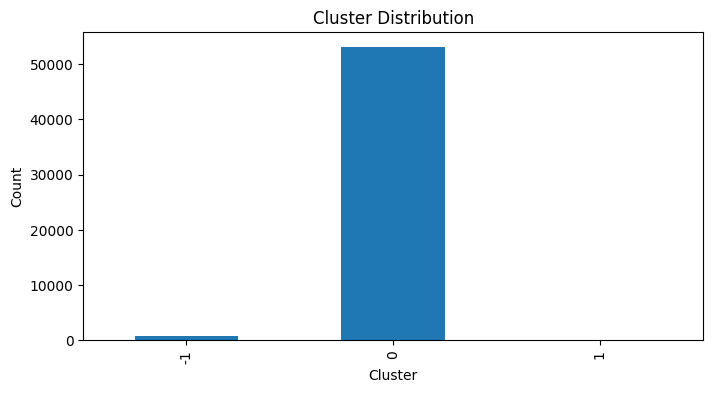

In [19]:
if cluster_assignments_df is not None and "cluster" in cluster_assignments_df.columns:
    cluster_assignments_df["cluster"].value_counts().sort_index().plot(kind="bar", figsize=(8, 4))
    plt.title("Cluster Distribution")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.show()
else:
    print("Cluster assignment data not available.")

## 13. Saved project reports

In [20]:
saved_reports = pd.DataFrame(
    {
        "report_name": [
            "processing_report",
            "feature_engineering_report",
            "regression_evaluation_report",
            "clustering_report",
            "model_selection_report",
            "pca_report",
        ],
        "available": [
            processing_report_text is not None,
            feature_engineering_report_text is not None,
            regression_report_text is not None,
            clustering_report_text is not None,
            model_selection_report_text is not None,
            pca_report_text is not None,
        ],
        "path": [
            str(paths["processing_report"]) if paths["processing_report"] else None,
            str(paths["feature_engineering_report"]) if paths["feature_engineering_report"] else None,
            str(paths["regression_report"]) if paths["regression_report"] else None,
            str(paths["clustering_report"]) if paths["clustering_report"] else None,
            str(paths["model_selection_report"]) if paths["model_selection_report"] else None,
            str(paths["pca_report"]) if paths["pca_report"] else None,
        ],
    }
)

saved_reports

,report_name,available,path
0,processing_report,True,F:\DATA SCIENCE\Projects\Diamond Dynamics Price Prediction and Market Segmentation\reports\processing_report.md
1,feature_engineering_report,True,F:\DATA SCIENCE\Projects\Diamond Dynamics Price Prediction and Market Segmentation\reports\feature_engineering_report.md
2,regression_evaluation_report,True,F:\DATA SCIENCE\Projects\Diamond Dynamics Price Prediction and Market Segmentation\reports\regression_evaluation_report.md
3,clustering_report,True,F:\DATA SCIENCE\Projects\Diamond Dynamics Price Prediction and Market Segmentation\reports\clustering_report.md
4,model_selection_report,True,F:\DATA SCIENCE\Projects\Diamond Dynamics Price Prediction and Market Segmentation\reports\model_selection_report.md
5,pca_report,True,F:\DATA SCIENCE\Projects\Diamond Dynamics Price Prediction and Market Segmentation\reports\pca_report.md


## 14. Key visuals

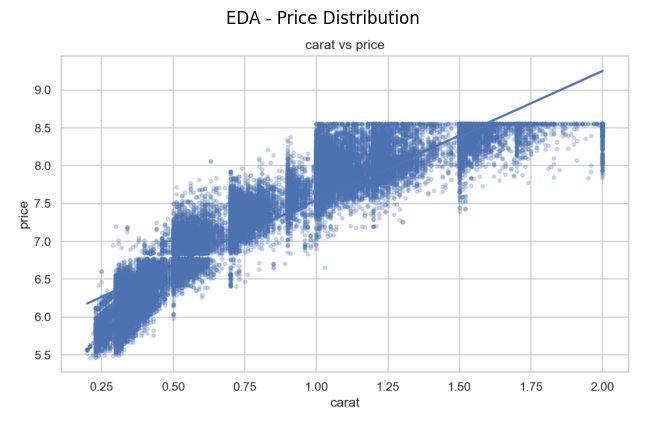

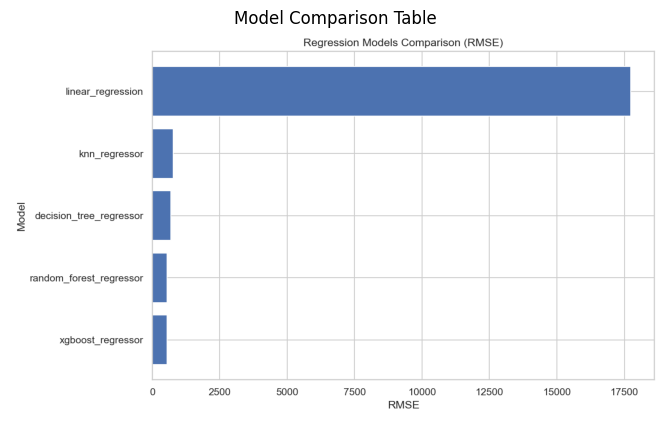

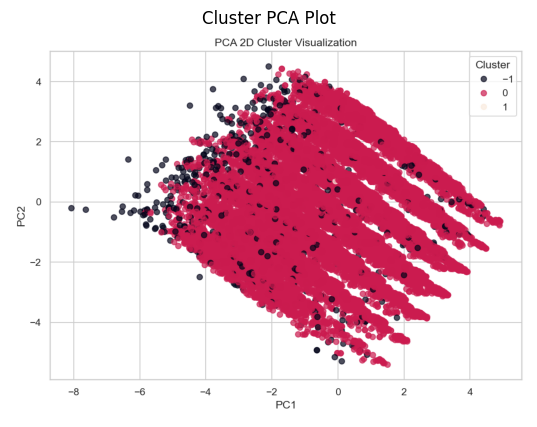

In [27]:
display_image(paths["eda_price_plot"], "EDA - Price Distribution", figsize=(10, 5))
display_image(paths["model_comparison_plot"], "Model Comparison Table", figsize=(10, 5))
display_image(paths["cluster_pca_plot"], "Cluster PCA Plot", figsize=(10, 5))

## 15. Streamlit application screenshots

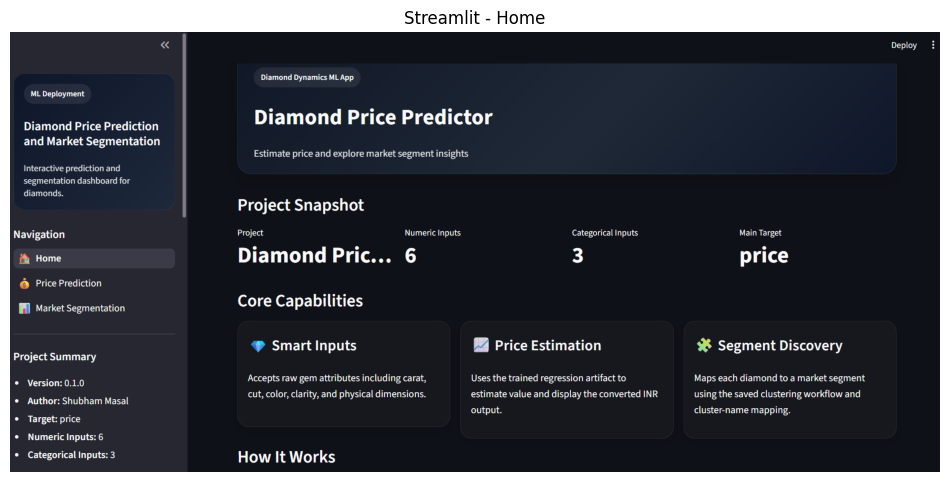

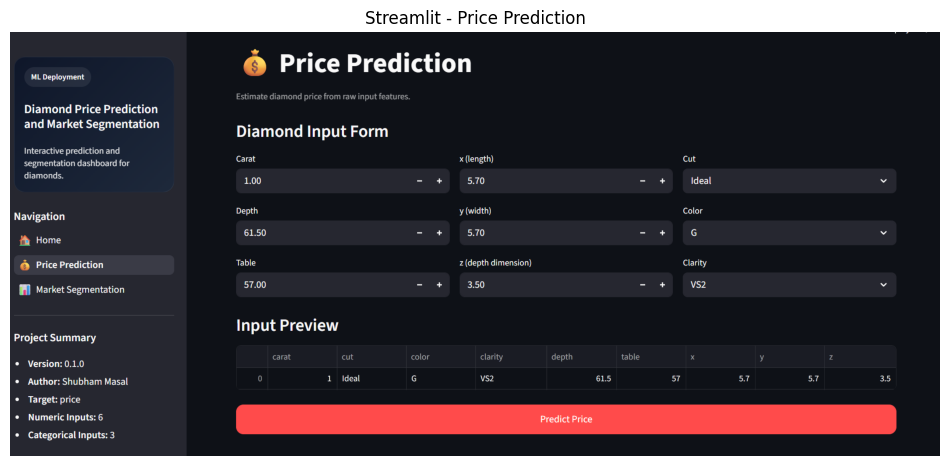

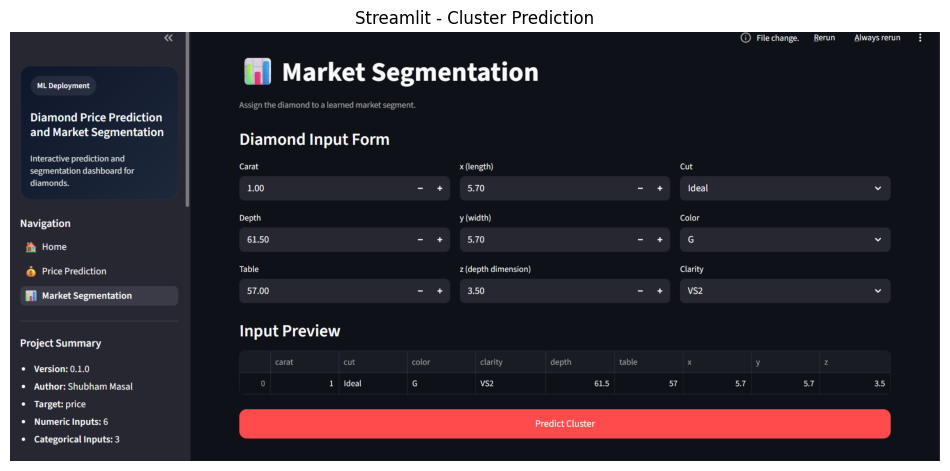

In [28]:
display_image(paths["streamlit_home"], "Streamlit - Home", figsize=(12, 6))
display_image(paths["streamlit_price"], "Streamlit - Price Prediction", figsize=(12, 6))
display_image(paths["streamlit_cluster"], "Streamlit - Cluster Prediction", figsize=(12, 6))

## 16. Final project outcome

In [29]:
project_outcome = {
    "cleaning_logic": "The pipeline validates schema, marks invalid x/y/z values as missing, removes impossible core rows, and imputes missing values.",
    "feature_engineering_logic": "The project adds domain-driven engineered features such as volume, dimension ratios, depth proportions, interaction terms, and carat transformations.",
    "regression_logic": "The regression workflow dynamically infers feature types, builds a preprocessing + estimator pipeline, trains multiple models, evaluates with MAE/MSE/RMSE/R2, ranks them, and saves artifacts.",
    "clustering_logic": "The clustering workflow prepares selected features, preprocesses them, compares KMeans, Agglomerative, and DBSCAN, then generates cluster summaries and human-readable segment names.",
    "deployment_logic": "The Streamlit app reuses shared input validation, runtime feature engineering, saved model artifacts, and inference helpers for both price prediction and segmentation.",
}

for key, value in project_outcome.items():
    print(f"- {value}")

- The pipeline validates schema, marks invalid x/y/z values as missing, removes impossible core rows, and imputes missing values.
- The project adds domain-driven engineered features such as volume, dimension ratios, depth proportions, interaction terms, and carat transformations.
- The regression workflow dynamically infers feature types, builds a preprocessing + estimator pipeline, trains multiple models, evaluates with MAE/MSE/RMSE/R2, ranks them, and saves artifacts.
- The clustering workflow prepares selected features, preprocesses them, compares KMeans, Agglomerative, and DBSCAN, then generates cluster summaries and human-readable segment names.
- The Streamlit app reuses shared input validation, runtime feature engineering, saved model artifacts, and inference helpers for both price prediction and segmentation.


## 17. Final conclusions

### Technical conclusions
- The project is a complete end-to-end ML system, not just a modeling notebook.
- The codebase is modular and split clearly across data, EDA, features, modeling, inference, visualization, and app layers.
- Runtime inference is consistent with training-time logic because the app reuses saved artifacts and the same feature engineering assumptions.

### Business conclusions
- The regression pipeline supports price estimation.
- The clustering pipeline supports market segmentation and inventory grouping.
- The combined system helps with pricing, catalog analysis, and business storytelling.

### Future extensions
- add SHAP explainability
- add batch CSV prediction in Streamlit
- deploy publicly
- add experiment tracking
- add model monitoring